# TEAM 04 — House Price Prediction Using Machine Learning

## Investigation of Informative, Irrelevant, and Redundant Features

**Course:** 24SJPCCST503 – Machine Learning  
**Academic Year:** 2026–2027  
**Team:** 04

### Research Question
> **Does adding more features necessarily improve prediction?**

### Investigation Question
> How does the type of added feature — informative, irrelevant, or redundant — affect predictive performance, generalization, stability, and model complexity in house-price prediction?

### Project principle
**Question → Hypothesis → Experiment → Evidence → Analysis → Conclusion**

This notebook is the supporting experimental evidence for the course project.

## 1. Hypotheses

### H1 — Informative features
Adding informative property features should generally improve predictive performance because they provide additional information about house prices.

### H2 — Irrelevant features
Adding features that contain no predictive information should not systematically improve predictive performance and may increase variability or generalization error.

### H3 — Redundant features
Adding highly redundant features should provide limited additional predictive benefit because their information is already represented by existing predictors.

### H4 — Model dependence
The effect of irrelevant and redundant features may differ between Ridge Regression and Random Forest because the two models learn relationships differently.

> **Important:** These are hypotheses, not expected results to be forced. The final conclusion must be based on the actual experimental evidence.

## 2. Experimental Architecture

We compare six controlled feature configurations:

| ID | Feature configuration | Main purpose |
|---|---|---|
| A | Core 10 informative features | Minimal meaningful baseline |
| B | Expanded 20 informative features | Effect of adding useful information |
| C | All original features | Full real-world feature set |
| D | All original + 10 irrelevant features | Effect of useless information |
| E | All original + 5 redundant features | Effect of repeated information |
| F | All original + irrelevant + redundant features | Combined effect |

Each configuration is evaluated using the **same train/test split**, the same preprocessing strategy, the same model settings, and the same evaluation metrics.

### Models
- Ridge Regression
- Random Forest Regressor

### Metrics
- RMSE
- MAE
- R²
- Train–test RMSE gap
- 5-fold cross-validation mean and standard deviation

### Additional evidence
- Correlation between original and deliberately redundant features
- Number of raw features
- Number of transformed/encoded model features

In [1]:
# 3. Import Libraries

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

## 4. Load the Ames Housing Dataset

### Expected file
This notebook is designed for the common Kaggle Ames Housing `train.csv` file, where:
- `SalePrice` is the target
- `Id` is an identifier and is excluded from the feature set

If your CSV has a different filename or location, change `DATA_PATH` below.

In [4]:
# Path to the dataset.
# The notebook lives in notebooks/ and the data lives in data/raw/.
# os.getcwd() in Jupyter returns the directory from which the server was started,
# which is typically the project root when you launch from there.
# If Jupyter is launched from inside notebooks/, adjust the path accordingly.
DATA_PATH = os.path.join(
    os.getcwd(),
    "..", "data", "raw", "train.csv"
)

# Normalize the path so error messages are readable
DATA_PATH = os.path.normpath(DATA_PATH)

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Could not find '{DATA_PATH}'. "
        "Please place train.csv at data/raw/train.csv "
        "relative to the project root, then re-run this cell."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.000,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.000,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.000,Unf,0.000,441.000,"1,080.000",GasA,Fa,Y,SBrkr,1656,0,0,1656,1.000,0.000,1,0,3,1,TA,7,Typ,2,Gd,Attchd,"1,960.000",Fin,2.000,528.000,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.000,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.000,TA,TA,CBlock,TA,TA,No,Rec,468.000,LwQ,144.000,270.000,882.000,GasA,TA,Y,SBrkr,896,0,0,896,0.000,0.000,1,0,2,1,TA,5,Typ,0,NaN,Attchd,"1,961.000",Unf,1.000,730.000,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.000,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.000,TA,TA,CBlock,TA,TA,No,ALQ,923.000,Unf,0.000,406.000,"1,329.000",GasA,TA,Y,SBrkr,1329,0,0,1329,0.000,0.000,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,"1,958.000",Unf,1.000,312.000,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.000,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.000,Gd,TA,CBlock,TA,TA,No,ALQ,"1,065.000",Unf,0.000,"1,045.000","2,110.000",GasA,Ex,Y,SBrkr,2110,0,0,2110,1.000,0.000,2,1,3,1,Ex,8,Typ,2,TA,Attchd,"1,968.000",Fin,2.000,522.000,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.000,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.000,TA,TA,PConc,Gd,TA,No,GLQ,791.000,Unf,0.000,137.000,928.000,GasA,Gd,Y,SBrkr,928,701,0,1629,0.000,0.000,2,1,3,1,TA,6,Typ,1,TA,Attchd,"1,997.000",Fin,2.000,482.000,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [5]:
# 5. Basic Dataset Inspection

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nTarget column present:", "SalePrice" in df.columns)
print("\nDuplicate rows:", df.duplicated().sum())

display(df.describe(include="all").T.head(20))

Rows: 2930
Columns: 82

Target column present: True

Duplicate rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Order,"2,930.000",NaN,NaN,NaN,"1,465.500",845.962,1.000,733.250,"1,465.500","2,197.750","2,930.000"
PID,"2,930.000",NaN,NaN,NaN,"714,464,496.989","188,730,844.649","526,301,100.000","528,477,022.500","535,453,620.000","907,181,097.500","1,007,100,110.000"
MS SubClass,"2,930.000",NaN,NaN,NaN,57.387,42.638,20.000,20.000,50.000,70.000,190.000
MS Zoning,2930,7,RL,2273,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lot Frontage,"2,440.000",NaN,NaN,NaN,69.225,23.365,21.000,58.000,68.000,80.000,313.000
Lot Area,"2,930.000",NaN,NaN,NaN,"10,147.922","7,880.018","1,300.000","7,440.250","9,436.500","11,555.250","215,245.000"
Street,2930,2,Pave,2918,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Alley,198,2,Grvl,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lot Shape,2930,4,Reg,1859,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Land Contour,2930,4,Lvl,2633,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Missing-value overview

missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

display(missing[missing > 0].head(20).to_frame("MissingValues"))

,MissingValues
Pool QC,2917
Misc Feature,2824
Alley,2732
Fence,2358
Mas Vnr Type,1775
Fireplace Qu,1422
Lot Frontage,490
Garage Cond,159
Garage Finish,159
Garage Yr Blt,159


## 6. Define Target and Predictors

`SalePrice` is the target variable.

`Id` is removed because it is an identifier rather than a property characteristic.

We keep the original feature columns unchanged at this stage. Missing values and categorical variables will be handled inside the preprocessing pipeline to avoid applying preprocessing outside the model-validation workflow.

In [7]:
TARGET = "SalePrice"

if TARGET not in df.columns:
    raise ValueError("The dataset must contain a 'SalePrice' target column.")

X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].copy()

if "Id" in X.columns:
    X = X.drop(columns=["Id"])

print("Predictor shape:", X.shape)
print("Target shape:", y.shape)

Predictor shape: (2930, 81)
Target shape: (2930,)


## 7. Train/Test Split

A single fixed 80/20 split is created for the main controlled comparison.

**Why fixed?**

Every feature configuration must be evaluated on the same observations. Otherwise, differences in performance could partly come from different train/test samples rather than from the feature configuration.

Cross-validation is used later as an additional reliability check.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 2344
Testing samples: 586


## 8. Define the Informative Feature Sets

The first two configurations use a deliberately small set of property attributes with clear domain relevance to house price, followed by an expanded set of additional property attributes.

### Core 10

In [10]:
print(X.columns.tolist())

['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt', 'Garage Finish', 'Garage Cars', 'Garage Area', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Wood Deck 

In [11]:
# Core 10 informative features
core_features = [
    "Overall Qual",
    "Gr Liv Area",
    "Garage Cars",
    "Total Bsmt SF",
    "1st Flr SF",
    "Year Built",
    "Year Remod/Add",
    "Full Bath",
    "TotRms AbvGrd",
    "Garage Area"
]

# Additional 10 informative features
expanded_additional_features = [
    "Overall Cond",
    "Bedroom AbvGr",
    "Fireplaces",
    "Garage Yr Blt",
    "Mas Vnr Area",
    "BsmtFin SF 1",
    "Bsmt Unf SF",
    "2nd Flr SF",
    "Wood Deck SF",
    "Open Porch SF"
]

expanded_features = core_features + expanded_additional_features

# Check that all selected features exist
missing_core = [f for f in core_features if f not in X.columns]
missing_expanded = [f for f in expanded_features if f not in X.columns]

print("Core features:", len(core_features))
print("Expanded features:", len(expanded_features))
print("Missing core features:", missing_core)
print("Missing expanded features:", missing_expanded)

if missing_core or missing_expanded:
    raise ValueError("One or more selected features are missing from the dataset.")

Core features: 10
Expanded features: 20
Missing core features: []
Missing expanded features: []


## 9. Create Controlled Irrelevant Features

We deliberately generate random variables independently of the target.

These are **experimental features**, not naturally occurring Ames variables.

The purpose is to create a controlled test of what happens when the model receives additional variables that contain no intentionally encoded predictive signal.

The random seed is fixed so that the experiment is reproducible.

In [12]:
rng = np.random.RandomState(RANDOM_STATE)

X_experiment = X.copy()

random_features = []

for i in range(10):
    feature_name = f"RandomFeature_{i+1}"
    X_experiment[feature_name] = rng.normal(
        loc=0,
        scale=1,
        size=len(X_experiment)
    )
    random_features.append(feature_name)

print("Irrelevant features created:", random_features)

Irrelevant features created: ['RandomFeature_1', 'RandomFeature_2', 'RandomFeature_3', 'RandomFeature_4', 'RandomFeature_5', 'RandomFeature_6', 'RandomFeature_7', 'RandomFeature_8', 'RandomFeature_9', 'RandomFeature_10']


## 10. Create Controlled Redundant Features

A redundant feature contains information that is already represented by another feature.

We construct highly correlated versions of five existing variables by applying a small transformation and adding a small amount of noise.

We then **measure the correlations** rather than assuming the features are redundant.

In [14]:
# Generate deliberately redundant features
# These are highly correlated versions of existing informative features.

rng = np.random.RandomState(42)

redundant_specs = {
    "Redundant_GrLivArea": ("Gr Liv Area", 1.02, 10),
    "Redundant_OverallQual": ("Overall Qual", 1.00, 0.20),
    "Redundant_GarageArea": ("Garage Area", 1.01, 5),
    "Redundant_TotalBsmtSF": ("Total Bsmt SF", 0.99, 10),
    "Redundant_YearBuilt": ("Year Built", 1.00, 2),
}

redundant_features = []

for new_name, (original_name, multiplier, noise_sd) in redundant_specs.items():
    X_experiment[new_name] = (
        X_experiment[original_name] * multiplier
        + rng.normal(0, noise_sd, len(X_experiment))
    )
    redundant_features.append(new_name)

print("Redundant features created:")
print(redundant_features)

Redundant features created:
['Redundant_GrLivArea', 'Redundant_OverallQual', 'Redundant_GarageArea', 'Redundant_TotalBsmtSF', 'Redundant_YearBuilt']


In [15]:
# Evidence that the constructed features are highly correlated with their originals

redundancy_evidence = []

for new_name, (original_name, _, _) in redundant_specs.items():
    correlation = X_experiment[original_name].corr(
        X_experiment[new_name]
    )

    redundancy_evidence.append({
        "Original Feature": original_name,
        "Redundant Feature": new_name,
        "Pearson Correlation": correlation
    })

redundancy_df = pd.DataFrame(redundancy_evidence)

display(redundancy_df.round(4))

,Original Feature,Redundant Feature,Pearson Correlation
0,Gr Liv Area,Redundant_GrLivArea,1.000
1,Overall Qual,Redundant_OverallQual,0.990
2,Garage Area,Redundant_GarageArea,1.000
3,Total Bsmt SF,Redundant_TotalBsmtSF,1.000
4,Year Built,Redundant_YearBuilt,0.998


## 11. Define the Six Experimental Conditions

Only the **feature set** changes between conditions.

The target, train/test split, preprocessing approach, model hyperparameters, and evaluation metrics remain controlled.

In [16]:
all_original_features = list(X.columns)

feature_sets = {
    "A_Core_10": core_features,
    "B_Informative_20": expanded_features,
    "C_All_Original": all_original_features,
    "D_Original_Plus_Irrelevant": all_original_features + random_features,
    "E_Original_Plus_Redundant": all_original_features + redundant_features,
    "F_Original_Plus_Both": (
        all_original_features + random_features + redundant_features
    ),
}

feature_summary = pd.DataFrame([
    {
        "Experiment": name,
        "Raw Feature Count": len(features),
        "Added Feature Type": {
            "A_Core_10": "None — baseline",
            "B_Informative_20": "10 additional informative",
            "C_All_Original": "Remaining original features",
            "D_Original_Plus_Irrelevant": "10 irrelevant random",
            "E_Original_Plus_Redundant": "5 redundant",
            "F_Original_Plus_Both": "10 irrelevant + 5 redundant",
        }[name]
    }
    for name, features in feature_sets.items()
])

display(feature_summary)

,Experiment,Raw Feature Count,Added Feature Type
0,A_Core_10,10,None — baseline
1,B_Informative_20,20,10 additional informative
2,C_All_Original,81,Remaining original features
3,D_Original_Plus_Irrelevant,91,10 irrelevant random
4,E_Original_Plus_Redundant,86,5 redundant
5,F_Original_Plus_Both,96,10 irrelevant + 5 redundant


## 12. Preprocessing

Ames contains both numerical and categorical variables.

### Numerical
- Median imputation
- Standardization for Ridge

### Categorical
- Most-frequent imputation
- One-hot encoding

The preprocessing is placed inside a scikit-learn `Pipeline`, so transformations are fitted only on the training portion during model fitting/cross-validation.

In [17]:
def make_one_hot_encoder():
    # Compatibility with different scikit-learn versions.
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=True
        )


def create_preprocessor(X_data, scale_numeric=True):
    numeric_features = X_data.select_dtypes(
        include=["int64", "float64", "int32", "float32"]
    ).columns.tolist()

    categorical_features = X_data.select_dtypes(
        include=["object", "category", "bool"]
    ).columns.tolist()

    numeric_steps = [
        ("imputer", SimpleImputer(strategy="median"))
    ]

    if scale_numeric:
        numeric_steps.append(
            ("scaler", StandardScaler())
        )

    numeric_pipeline = Pipeline(numeric_steps)

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", make_one_hot_encoder())
    ])

    transformers = []

    if numeric_features:
        transformers.append(
            ("num", numeric_pipeline, numeric_features)
        )

    if categorical_features:
        transformers.append(
            ("cat", categorical_pipeline, categorical_features)
        )

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop"
    )

## 13. Models

We use two deliberately different regression approaches.

### Ridge Regression
A regularized linear model. It provides a useful reference for studying linear relationships and correlated predictors.

### Random Forest Regressor
A nonlinear tree-based ensemble. It allows us to investigate whether feature effects are similar for a substantially different learning approach.

The hyperparameters remain fixed across all feature configurations so that the controlled variable is the **feature set**, not model tuning.

In [18]:
def make_models():
    return {
        "Ridge": Ridge(alpha=10.0),
        "Random Forest": RandomForestRegressor(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    }

## 14. Evaluation Function

For each experiment and model we record:

- Training RMSE
- Test RMSE
- Test MAE
- Test R²
- Generalization gap = Test RMSE − Train RMSE
- Number of transformed model features

In [19]:
def evaluate_single_split(model, X_train_exp, X_test_exp, y_train, y_test):
    model.fit(X_train_exp, y_train)

    train_pred = model.predict(X_train_exp)
    test_pred = model.predict(X_test_exp)

    train_rmse = np.sqrt(
        mean_squared_error(y_train, train_pred)
    )

    test_rmse = np.sqrt(
        mean_squared_error(y_test, test_pred)
    )

    test_mae = mean_absolute_error(
        y_test, test_pred
    )

    test_r2 = r2_score(
        y_test, test_pred
    )

    return {
        "Train_RMSE": train_rmse,
        "Test_RMSE": test_rmse,
        "Test_MAE": test_mae,
        "Test_R2": test_r2,
        "Generalization_Gap": test_rmse - train_rmse,
    }

## 15. Main Controlled Experiment

The same train/test indices are reused for every configuration.

This is the core experiment of the project.

In [20]:
main_results = []
transformed_feature_counts = []

for experiment_name, features in feature_sets.items():

    X_train_exp = X_experiment.loc[X_train.index, features].copy()
    X_test_exp = X_experiment.loc[X_test.index, features].copy()

    for model_name, estimator in make_models().items():

        preprocessor = create_preprocessor(
            X_train_exp,
            scale_numeric=(model_name == "Ridge")
        )

        pipeline = Pipeline([
            ("preprocessing", preprocessor),
            ("model", estimator)
        ])

        metrics = evaluate_single_split(
            pipeline,
            X_train_exp,
            X_test_exp,
            y_train,
            y_test
        )

        fitted_preprocessor = pipeline.named_steps["preprocessing"]
        transformed_count = len(
            fitted_preprocessor.get_feature_names_out()
        )

        main_results.append({
            "Experiment": experiment_name,
            "Model": model_name,
            "Raw_Features": len(features),
            "Transformed_Features": transformed_count,
            **metrics
        })

        transformed_feature_counts.append({
            "Experiment": experiment_name,
            "Model": model_name,
            "Raw_Features": len(features),
            "Transformed_Features": transformed_count
        })

main_results_df = pd.DataFrame(main_results)

display(
    main_results_df
    .sort_values(["Model", "Experiment"])
    .round(3)
)

,Experiment,Model,Raw_Features,Transformed_Features,Train_RMSE,Test_RMSE,Test_MAE,Test_R2,Generalization_Gap
1,A_Core_10,Random Forest,10,10,"10,780.842","31,658.027","18,053.324",0.875,"20,877.185"
3,B_Informative_20,Random Forest,20,20,"10,026.849","27,758.095","16,138.034",0.904,"17,731.246"
5,C_All_Original,Random Forest,81,302,"9,846.204","26,711.359","15,867.277",0.911,"16,865.155"
7,D_Original_Plus_Irrelevant,Random Forest,91,312,"10,056.867","27,560.391","16,294.933",0.905,"17,503.524"
9,E_Original_Plus_Redundant,Random Forest,86,307,"9,918.657","26,892.592","15,925.157",0.910,"16,973.935"
11,F_Original_Plus_Both,Random Forest,96,317,"10,194.785","27,631.613","16,441.177",0.905,"17,436.828"
0,A_Core_10,Ridge,10,10,"35,288.604","39,548.984","24,841.636",0.805,"4,260.380"
2,B_Informative_20,Ridge,20,20,"33,467.131","36,621.425","22,340.125",0.833,"3,154.294"
4,C_All_Original,Ridge,81,302,"22,951.019","29,160.886","16,579.318",0.894,"6,209.867"
6,D_Original_Plus_Irrelevant,Ridge,91,312,"22,905.338","29,082.412","16,544.567",0.895,"6,177.074"


## 16. Main Results — Easier-to-Read Table

In [21]:
results_display = main_results_df.copy()

numeric_cols = [
    "Train_RMSE",
    "Test_RMSE",
    "Test_MAE",
    "Test_R2",
    "Generalization_Gap"
]

display(
    results_display[
        [
            "Experiment",
            "Model",
            "Raw_Features",
            "Transformed_Features",
            *numeric_cols
        ]
    ].round(3)
)

,Experiment,Model,Raw_Features,Transformed_Features,Train_RMSE,Test_RMSE,Test_MAE,Test_R2,Generalization_Gap
0,A_Core_10,Ridge,10,10,"35,288.604","39,548.984","24,841.636",0.805,"4,260.380"
1,A_Core_10,Random Forest,10,10,"10,780.842","31,658.027","18,053.324",0.875,"20,877.185"
2,B_Informative_20,Ridge,20,20,"33,467.131","36,621.425","22,340.125",0.833,"3,154.294"
3,B_Informative_20,Random Forest,20,20,"10,026.849","27,758.095","16,138.034",0.904,"17,731.246"
4,C_All_Original,Ridge,81,302,"22,951.019","29,160.886","16,579.318",0.894,"6,209.867"
5,C_All_Original,Random Forest,81,302,"9,846.204","26,711.359","15,867.277",0.911,"16,865.155"
6,D_Original_Plus_Irrelevant,Ridge,91,312,"22,905.338","29,082.412","16,544.567",0.895,"6,177.074"
7,D_Original_Plus_Irrelevant,Random Forest,91,312,"10,056.867","27,560.391","16,294.933",0.905,"17,503.524"
8,E_Original_Plus_Redundant,Ridge,86,307,"22,954.772","29,175.642","16,594.005",0.894,"6,220.871"
9,E_Original_Plus_Redundant,Random Forest,86,307,"9,918.657","26,892.592","15,925.157",0.910,"16,973.935"


## 17. Visualization 1 — Feature Quantity vs Test RMSE

This directly addresses the central research question.

A lower RMSE means smaller prediction error.

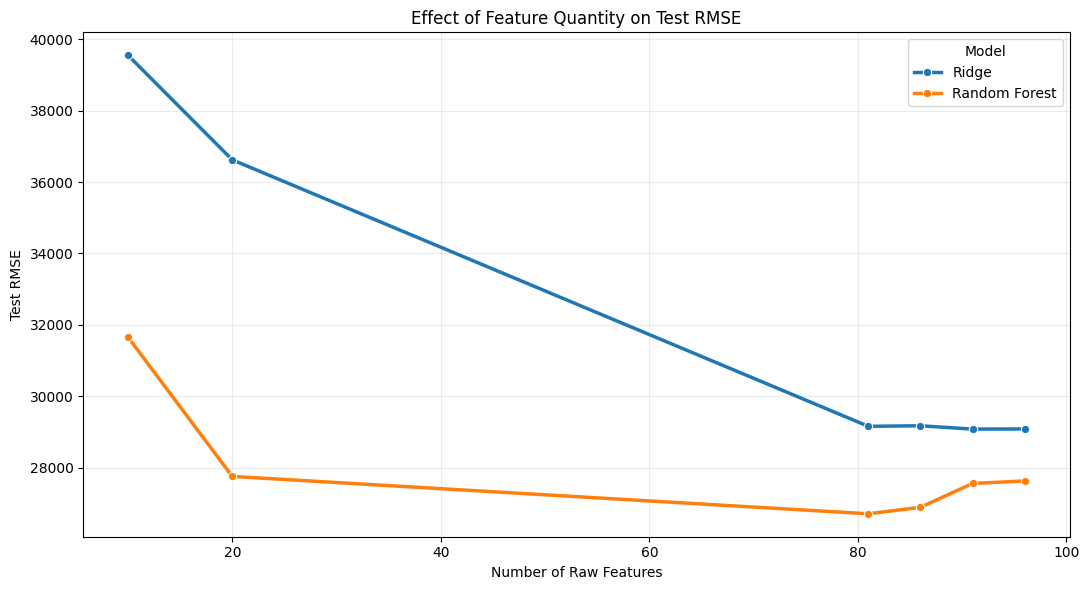

In [22]:
plt.figure(figsize=(11, 6))

sns.lineplot(
    data=main_results_df,
    x="Raw_Features",
    y="Test_RMSE",
    hue="Model",
    marker="o",
    linewidth=2.5
)

plt.title("Effect of Feature Quantity on Test RMSE")
plt.xlabel("Number of Raw Features")
plt.ylabel("Test RMSE")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 18. Visualization 2 — Feature Configuration vs R²

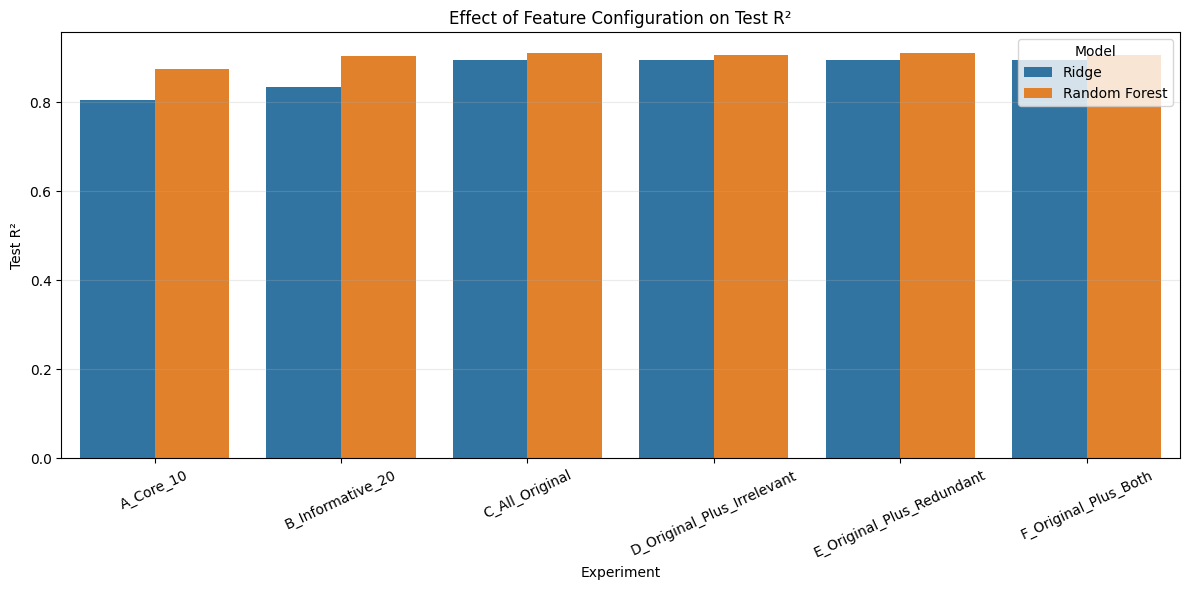

In [23]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=main_results_df,
    x="Experiment",
    y="Test_R2",
    hue="Model"
)

plt.title("Effect of Feature Configuration on Test R²")
plt.xlabel("Experiment")
plt.ylabel("Test R²")
plt.xticks(rotation=25)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## 19. Visualization 3 — Training vs Test RMSE

The training–test difference helps us discuss generalization.

A larger gap means the model's training error is much lower than its test error.
This is evidence to interpret, not by itself proof of overfitting.

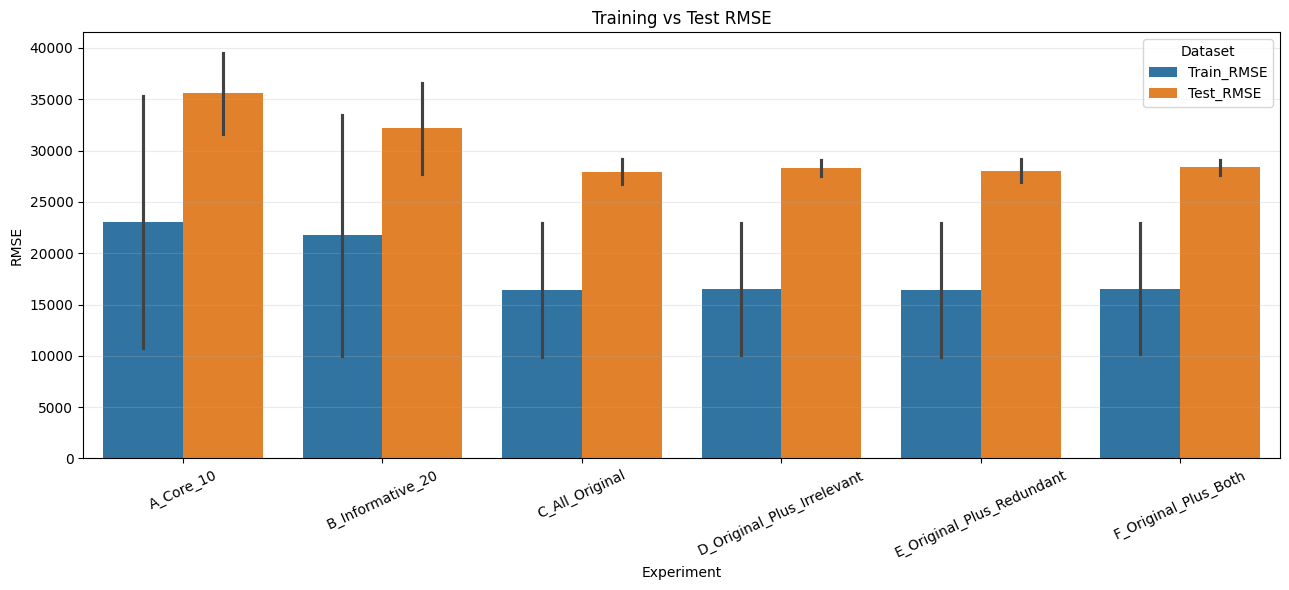

In [24]:
plot_df = main_results_df.melt(
    id_vars=["Experiment", "Model"],
    value_vars=["Train_RMSE", "Test_RMSE"],
    var_name="Dataset",
    value_name="RMSE"
)

plt.figure(figsize=(13, 6))

sns.barplot(
    data=plot_df,
    x="Experiment",
    y="RMSE",
    hue="Dataset"
)

plt.title("Training vs Test RMSE")
plt.xlabel("Experiment")
plt.ylabel("RMSE")
plt.xticks(rotation=25)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## 20. Five-Fold Cross-Validation

The fixed train/test comparison is complemented by 5-fold cross-validation.

For each configuration and model we record:
- Mean CV RMSE
- Standard deviation of CV RMSE
- Mean CV MAE
- Mean CV R²

The standard deviation provides evidence about performance variability across folds.

In [25]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_results = []

for experiment_name, features in feature_sets.items():

    X_exp = X_experiment[features].copy()

    for model_name, estimator in make_models().items():

        preprocessor = create_preprocessor(
            X_exp,
            scale_numeric=(model_name == "Ridge")
        )

        pipeline = Pipeline([
            ("preprocessing", preprocessor),
            ("model", estimator)
        ])

        scores = cross_validate(
            pipeline,
            X_exp,
            y,
            cv=cv,
            scoring={
                "RMSE": "neg_root_mean_squared_error",
                "MAE": "neg_mean_absolute_error",
                "R2": "r2"
            },
            n_jobs=-1,
            return_train_score=False
        )

        cv_results.append({
            "Experiment": experiment_name,
            "Model": model_name,
            "Raw_Features": len(features),
            "CV_RMSE_Mean": -scores["test_RMSE"].mean(),
            "CV_RMSE_STD": scores["test_RMSE"].std(),
            "CV_MAE_Mean": -scores["test_MAE"].mean(),
            "CV_R2_Mean": scores["test_R2"].mean()
        })

cv_df = pd.DataFrame(cv_results)

display(cv_df.round(3))

,Experiment,Model,Raw_Features,CV_RMSE_Mean,CV_RMSE_STD,CV_MAE_Mean,CV_R2_Mean
0,A_Core_10,Ridge,10,"36,540.358","3,146.353","23,553.763",0.787
1,A_Core_10,Random Forest,10,"28,197.520","2,334.332","18,075.260",0.874
2,B_Informative_20,Ridge,20,"34,682.306","3,730.591","21,550.896",0.806
3,B_Informative_20,Random Forest,20,"26,347.258","1,358.039","16,420.580",0.889
4,C_All_Original,Ridge,81,"27,901.076","3,759.141","15,933.315",0.873
5,C_All_Original,Random Forest,81,"25,464.424","1,149.518","15,661.268",0.897
6,D_Original_Plus_Irrelevant,Ridge,91,"27,915.137","3,738.404","15,997.779",0.873
7,D_Original_Plus_Irrelevant,Random Forest,91,"26,070.742","1,231.130","16,045.780",0.892
8,E_Original_Plus_Redundant,Ridge,86,"27,911.460","3,771.718","15,937.736",0.873
9,E_Original_Plus_Redundant,Random Forest,86,"25,750.131","1,294.581","15,852.205",0.895


## 21. Visualization 4 — Cross-Validation RMSE ± Standard Deviation

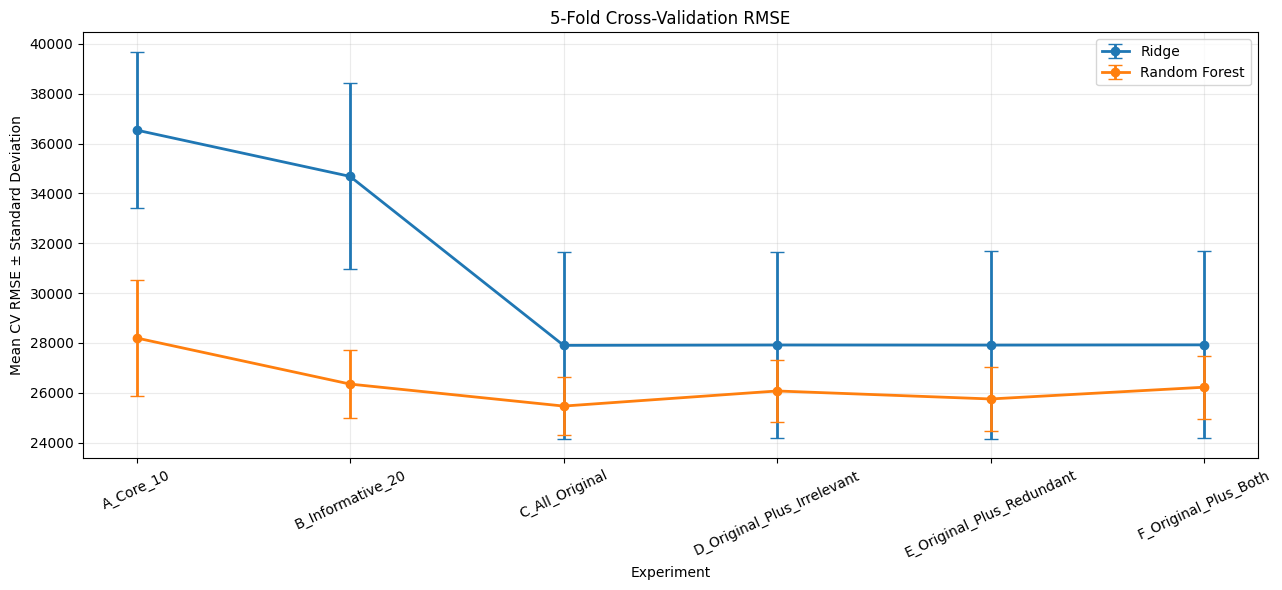

In [26]:
plt.figure(figsize=(13, 6))

for model_name in cv_df["Model"].unique():
    subset = cv_df[cv_df["Model"] == model_name]

    plt.errorbar(
        subset["Experiment"],
        subset["CV_RMSE_Mean"],
        yerr=subset["CV_RMSE_STD"],
        marker="o",
        capsize=5,
        linewidth=2,
        label=model_name
    )

plt.title("5-Fold Cross-Validation RMSE")
plt.xlabel("Experiment")
plt.ylabel("Mean CV RMSE ± Standard Deviation")
plt.xticks(rotation=25)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## 22. Visualization 5 — Original vs Redundant Features

This heatmap provides direct evidence that the deliberately constructed redundant variables are highly correlated with their source variables.

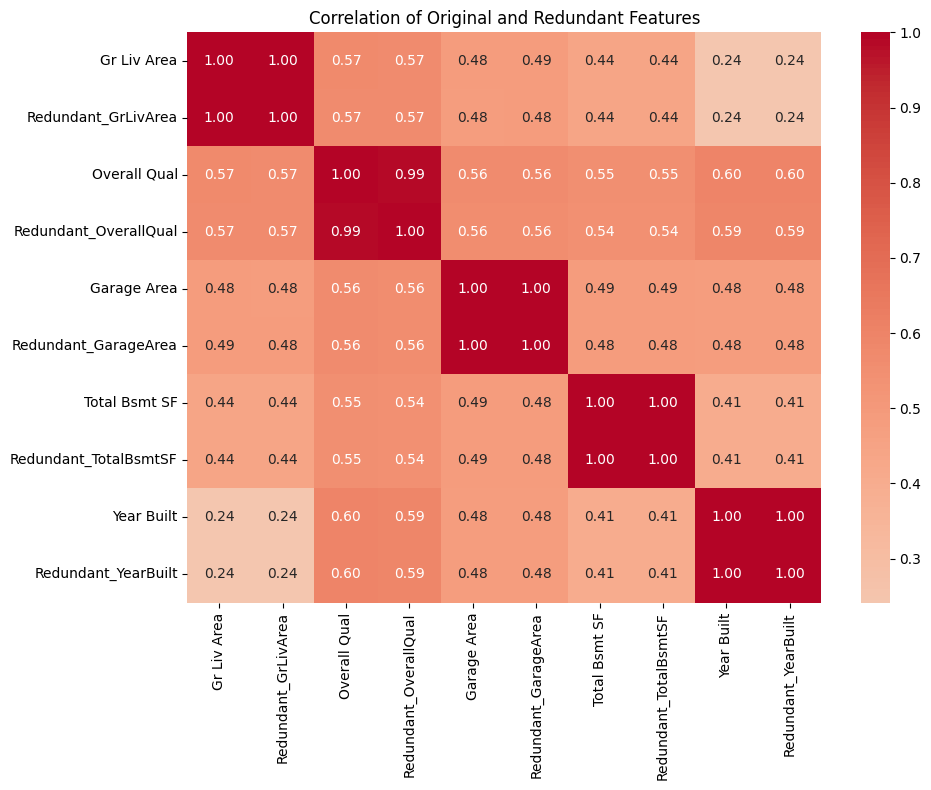

In [27]:
corr_features = []

for original_name, new_name, _ in [
    (v[0], k, None) for k, v in redundant_specs.items()
]:
    corr_features.extend([original_name, new_name])

# Remove duplicates while preserving order
corr_features = list(dict.fromkeys(corr_features))

plt.figure(figsize=(10, 8))

sns.heatmap(
    X_experiment[corr_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation of Original and Redundant Features")
plt.tight_layout()
plt.show()

## 23. Model Complexity Evidence

Raw feature count is not the same as the final number of model inputs because categorical variables are one-hot encoded.

The transformed-feature count shows how the feature configuration changes the actual dimensionality seen by the models.

In [28]:
complexity_df = (
    main_results_df[
        ["Experiment", "Model", "Raw_Features", "Transformed_Features"]
    ]
    .drop_duplicates()
    .sort_values(["Model", "Experiment"])
)

display(complexity_df)

,Experiment,Model,Raw_Features,Transformed_Features
1,A_Core_10,Random Forest,10,10
3,B_Informative_20,Random Forest,20,20
5,C_All_Original,Random Forest,81,302
7,D_Original_Plus_Irrelevant,Random Forest,91,312
9,E_Original_Plus_Redundant,Random Forest,86,307
11,F_Original_Plus_Both,Random Forest,96,317
0,A_Core_10,Ridge,10,10
2,B_Informative_20,Ridge,20,20
4,C_All_Original,Ridge,81,302
6,D_Original_Plus_Irrelevant,Ridge,91,312


## 24. Optional: Compare Feature-Configuration Changes Directly

This table makes the controlled comparisons explicit:

- **A → B:** add informative features
- **C → D:** add irrelevant features
- **C → E:** add redundant features
- **C → F:** add both irrelevant and redundant features

In [29]:
comparison_pairs = [
    ("A_Core_10", "B_Informative_20", "Additional informative features"),
    ("C_All_Original", "D_Original_Plus_Irrelevant", "Additional irrelevant features"),
    ("C_All_Original", "E_Original_Plus_Redundant", "Additional redundant features"),
    ("C_All_Original", "F_Original_Plus_Both", "Irrelevant + redundant features"),
]

comparison_rows = []

for base, modified, change_description in comparison_pairs:
    for model_name in main_results_df["Model"].unique():

        base_row = main_results_df[
            (main_results_df["Experiment"] == base) &
            (main_results_df["Model"] == model_name)
        ].iloc[0]

        modified_row = main_results_df[
            (main_results_df["Experiment"] == modified) &
            (main_results_df["Model"] == model_name)
        ].iloc[0]

        comparison_rows.append({
            "Model": model_name,
            "Comparison": f"{base} → {modified}",
            "Feature Change": change_description,
            "Δ Test RMSE": modified_row["Test_RMSE"] - base_row["Test_RMSE"],
            "Δ Test MAE": modified_row["Test_MAE"] - base_row["Test_MAE"],
            "Δ Test R²": modified_row["Test_R2"] - base_row["Test_R2"],
            "Δ Generalization Gap": (
                modified_row["Generalization_Gap"]
                - base_row["Generalization_Gap"]
            )
        })

comparison_df = pd.DataFrame(comparison_rows)

display(comparison_df.round(3))

,Model,Comparison,Feature Change,Δ Test RMSE,Δ Test MAE,Δ Test R²,Δ Generalization Gap
0,Ridge,A_Core_10 → B_Informative_20,Additional informative features,"-2,927.559","-2,501.511",0.028,"-1,106.086"
1,Random Forest,A_Core_10 → B_Informative_20,Additional informative features,"-3,899.932","-1,915.289",0.029,"-3,145.939"
2,Ridge,C_All_Original → D_Original_Plus_Irrelevant,Additional irrelevant features,-78.474,-34.751,0.001,-32.793
3,Random Forest,C_All_Original → D_Original_Plus_Irrelevant,Additional irrelevant features,849.033,427.656,-0.006,638.369
4,Ridge,C_All_Original → E_Original_Plus_Redundant,Additional redundant features,14.757,14.687,-0.000,11.004
5,Random Forest,C_All_Original → E_Original_Plus_Redundant,Additional redundant features,181.234,57.880,-0.001,108.781
6,Ridge,C_All_Original → F_Original_Plus_Both,Irrelevant + redundant features,-73.676,-33.140,0.001,-28.335
7,Random Forest,C_All_Original → F_Original_Plus_Both,Irrelevant + redundant features,920.254,573.900,-0.006,571.673


# 25. Analysis Guide — Complete This After Running the Experiments

**Do not write the final conclusion before seeing the actual results.**

Use the following questions to analyze the evidence.

### A. Informative features
1. Did A → B improve test RMSE, MAE, or R²?
2. Did B → C continue the same trend?
3. Were the improvements consistent across Ridge and Random Forest?
4. Did cross-validation support the test-set observation?

### B. Irrelevant features
1. What changed from C → D?
2. Did irrelevant features improve, worsen, or leave performance approximately unchanged?
3. Was the change larger than the observed cross-validation variability?
4. Did the train–test gap change?

### C. Redundant features
1. What changed from C → E?
2. Did the redundant features provide additional predictive benefit?
3. Did the correlation evidence support the definition of redundancy?
4. Did Ridge and Random Forest react similarly?

### D. Combined condition
1. What happened in F?
2. Was the combined effect simply additive, or different from the individual effects?
3. Did the model's transformed feature count increase substantially?

### E. Model dependence
1. Did Ridge and Random Forest show the same pattern?
2. If not, what property of the models could explain the difference?

### F. Reliability
1. Are the observations visible on the fixed test set also visible in 5-fold CV?
2. Are the differences large relative to CV standard deviation?
3. What limitations prevent us from making a stronger claim?

### Final conclusion format

**What happened?**  
State the observed evidence.

**Why did it happen?**  
Connect the observation to feature information, redundancy, model behaviour, and generalization.

**How confidently can we conclude it?**  
Use cross-validation variability and experimental limitations.

# 26. Limitations to Consider

1. The irrelevant features are artificially generated random variables, so they do not represent every type of irrelevant real-world feature.
2. The redundant features are deliberately constructed from existing variables, so real-world redundancy may behave differently.
3. The Ames dataset represents a particular housing market and historical dataset, so the findings should not automatically be generalized to every housing market.
4. Only two regression models are studied; other algorithms may respond differently.
5. A fixed train/test split is useful for controlled comparison, but cross-validation is needed to assess variability.

# 27. AI Usage Declaration — Draft

The course requires honest disclosure of AI assistance.

### AI tool(s) used
ChatGPT

### Purpose of using AI
- Understanding machine-learning concepts
- Planning the experimental design
- Generating and debugging notebook code
- Suggesting visualizations and analysis questions

### Parts of the project assisted by AI
- Notebook structure
- Experimental pipeline
- Feature-configuration implementation
- Evaluation and visualization code

### How the AI-generated output was verified
The team will execute and test the notebook, inspect the generated results, verify the methodology, and independently interpret the evidence.

### One AI suggestion that we modified, rejected, or corrected
**To be completed by the team after reviewing the notebook and experimental results.**

# 28. Final Checklist

Before submission:

- [ ] Research question clearly matches Team 04
- [ ] Hypotheses stated before experiments
- [ ] Six feature configurations implemented
- [ ] Informative features clearly defined
- [ ] Irrelevant features deliberately generated and documented
- [ ] Redundant features deliberately generated and correlation verified
- [ ] Same train/test split used for controlled comparisons
- [ ] Same model hyperparameters used across feature conditions
- [ ] Ridge Regression evaluated
- [ ] Random Forest evaluated
- [ ] RMSE, MAE and R² reported
- [ ] Training vs test performance analyzed
- [ ] 5-fold cross-validation performed
- [ ] Mean and standard deviation reported
- [ ] At least two limitations discussed
- [ ] Final conclusions based on actual results
- [ ] No results fabricated or manipulated
- [ ] AI usage honestly declared

## 26. Save Results

Run this cell after completing the full experiment to write the results and figures to disk.

Files are saved relative to the project root (one level above this notebook).

In [ ]:
# Resolve the project root (parent of the notebooks/ folder)
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

TABLES_DIR = os.path.join(PROJECT_ROOT, "results", "tables")
FIGURES_DIR = os.path.join(PROJECT_ROOT, "results", "figures")

os.makedirs(TABLES_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── Save numerical tables ──────────────────────────────────────────────────

main_results_df.to_csv(
    os.path.join(TABLES_DIR, "main_results.csv"),
    index=False
)

cv_df.to_csv(
    os.path.join(TABLES_DIR, "cv_results.csv"),
    index=False
)

feature_summary.to_csv(
    os.path.join(TABLES_DIR, "feature_summary.csv"),
    index=False
)

redundancy_df.to_csv(
    os.path.join(TABLES_DIR, "redundancy_evidence.csv"),
    index=False
)

print("Tables saved to:", TABLES_DIR)

# ── Save figures ────────────────────────────────────────────────────────────

# Figure 1: Feature count vs Test RMSE
fig1, ax1 = plt.subplots(figsize=(9, 5))
sns.lineplot(
    data=main_results_df,
    x="Raw_Features",
    y="Test_RMSE",
    hue="Model",
    marker="o",
    ax=ax1
)
ax1.set_title("Feature Count vs Test RMSE")
ax1.set_xlabel("Raw Feature Count")
ax1.set_ylabel("Test RMSE")
ax1.grid(True, alpha=0.3)
fig1.tight_layout()
fig1.savefig(
    os.path.join(FIGURES_DIR, "feature_count_vs_rmse.png"),
    dpi=150
)
plt.close(fig1)

# Figure 2: Configuration vs R²
fig2, ax2 = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=main_results_df,
    x="Experiment",
    y="Test_R2",
    hue="Model",
    ax=ax2
)
ax2.set_title("Feature Configuration vs Test R²")
ax2.set_xlabel("Experiment")
ax2.set_ylabel("Test R²")
ax2.tick_params(axis="x", rotation=30)
ax2.grid(True, alpha=0.3, axis="y")
fig2.tight_layout()
fig2.savefig(
    os.path.join(FIGURES_DIR, "configuration_vs_r2.png"),
    dpi=150
)
plt.close(fig2)

# Figure 3: Train vs Test RMSE
plot_df = main_results_df.melt(
    id_vars=["Experiment", "Model"],
    value_vars=["Train_RMSE", "Test_RMSE"],
    var_name="Split",
    value_name="RMSE"
)
fig3, ax3 = plt.subplots(figsize=(13, 5))
sns.barplot(
    data=plot_df,
    x="Experiment",
    y="RMSE",
    hue="Split",
    ax=ax3
)
ax3.set_title("Train vs Test RMSE by Feature Configuration")
ax3.set_xlabel("Experiment")
ax3.set_ylabel("RMSE")
ax3.tick_params(axis="x", rotation=30)
ax3.grid(True, alpha=0.3, axis="y")
fig3.tight_layout()
fig3.savefig(
    os.path.join(FIGURES_DIR, "train_vs_test_rmse.png"),
    dpi=150
)
plt.close(fig3)

# Figure 4: Cross-validation RMSE comparison
fig4, ax4 = plt.subplots(figsize=(11, 5))
x = range(len(cv_df))
ax4.bar(
    x,
    cv_df["CV_RMSE_Mean"],
    yerr=cv_df["CV_RMSE_Std"],
    capsize=4,
    alpha=0.8
)
ax4.set_xticks(list(x))
ax4.set_xticklabels(
    [
        f"{row['Experiment']}\n{row['Model']}"
        for _, row in cv_df.iterrows()
    ],
    rotation=30,
    ha="right",
    fontsize=7
)
ax4.set_title("5-Fold CV RMSE Mean ± Std")
ax4.set_ylabel("CV RMSE")
ax4.grid(True, alpha=0.3, axis="y")
fig4.tight_layout()
fig4.savefig(
    os.path.join(FIGURES_DIR, "cv_rmse_comparison.png"),
    dpi=150
)
plt.close(fig4)

# Figure 5: Redundancy correlation
fig5, ax5 = plt.subplots(figsize=(8, 4))
ax5.barh(
    redundancy_df["Redundant Feature"],
    redundancy_df["Pearson Correlation"],
    color="steelblue",
    alpha=0.85
)
ax5.set_xlabel("Pearson Correlation with Original")
ax5.set_title("Correlation: Redundant Features vs Their Originals")
ax5.set_xlim(0, 1.05)
ax5.grid(True, alpha=0.3, axis="x")
fig5.tight_layout()
fig5.savefig(
    os.path.join(FIGURES_DIR, "redundancy_correlation.png"),
    dpi=150
)
plt.close(fig5)

print("Figures saved to:", FIGURES_DIR)
print("\nAll results saved successfully.")